# Loading Necessary Libraries

In [1]:
# Loading Necessary Libraries
import pandas as pd
import numpy as np
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from tabulate import tabulate

# Data Loading

In [2]:

# fetch dataset
chronic_kidney_disease = fetch_ucirepo(id=336)

# data (as pandas dataframes)
X = chronic_kidney_disease.data.features
y = chronic_kidney_disease.data.targets

# variable information
print(chronic_kidney_disease.variables)


     name     role         type demographic              description  \
0     age  Feature      Integer         Age                     None   
1      bp  Feature      Integer        None           blood pressure   
2      sg  Feature  Categorical        None         specific gravity   
3      al  Feature  Categorical        None                  albumin   
4      su  Feature  Categorical        None                    sugar   
5     rbc  Feature       Binary        None          red blood cells   
6      pc  Feature       Binary        None                 pus cell   
7     pcc  Feature       Binary        None          pus cell clumps   
8      ba  Feature       Binary        None                 bacteria   
9     bgr  Feature      Integer        None     blood glucose random   
10     bu  Feature      Integer        None               blood urea   
11     sc  Feature   Continuous        None         serum creatinine   
12    sod  Feature      Integer        None                   so

In [3]:
# Check the first few rows of the dataset
print("First few rows of the dataset:")
X.head()

First few rows of the dataset:


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,11.3,38.0,6000.0,NaN,no,no,no,good,no,no
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,11.6,35.0,7300.0,4.6,no,no,no,good,no,no


In [4]:
# Check the dimensions of the dataset
print("\nDimensions of the dataset:")
print(X.shape)


Dimensions of the dataset:
(400, 24)


In [5]:
# Check for missing values
print("\nMissing values in the dataset:")
print(X.isnull().sum())


Missing values in the dataset:
age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       71
wbcc     106
rbcc     131
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
dtype: int64


In [6]:
# Basic statistics of the dataset
print("\nBasic statistics of the dataset:")
X.describe()


Basic statistics of the dataset:


,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [7]:
# Check the distribution of the target variable
print("\nDistribution of the target variable:")
print(y.value_counts())


Distribution of the target variable:
class 
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


# Data Cleaning

In [8]:
# Join X and y
data = X.copy()
data['class'] = y

In [9]:
# Clean target variable by removing '\t'
data['class'] = data['class'].replace({'ckd\t': 'ckd'})

In [10]:
# Separate numerical and categorical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = data.select_dtypes(include=['object']).columns

# Impute missing values for numerical features with KNNImputer
imputer = KNNImputer(n_neighbors=3)
data_imputed_numerical = pd.DataFrame(imputer.fit_transform(data[numerical_cols]), columns=numerical_cols)

# Impute missing values for categorical features with mode
data_imputed_categorical = data[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))

# Combine both numerical and categorical features back together
data_imputed = pd.concat([data_imputed_numerical, data_imputed_categorical], axis=1)

# Check if there are any missing values left
print("\nMissing values in the cleaned dataset after imputation:")
print(data_imputed.isnull().sum())

# Check the distribution of the target variable after cleaning
print("\nDistribution of the target variable after cleaning:")
print(data_imputed['class'].value_counts())


Missing values in the cleaned dataset after imputation:
age      0
bp       0
sg       0
al       0
su       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
rbc      0
pc       0
pcc      0
ba       0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64

Distribution of the target variable after cleaning:
class
ckd       250
notckd    150
Name: count, dtype: int64


# EDA

## Univariate Analysis

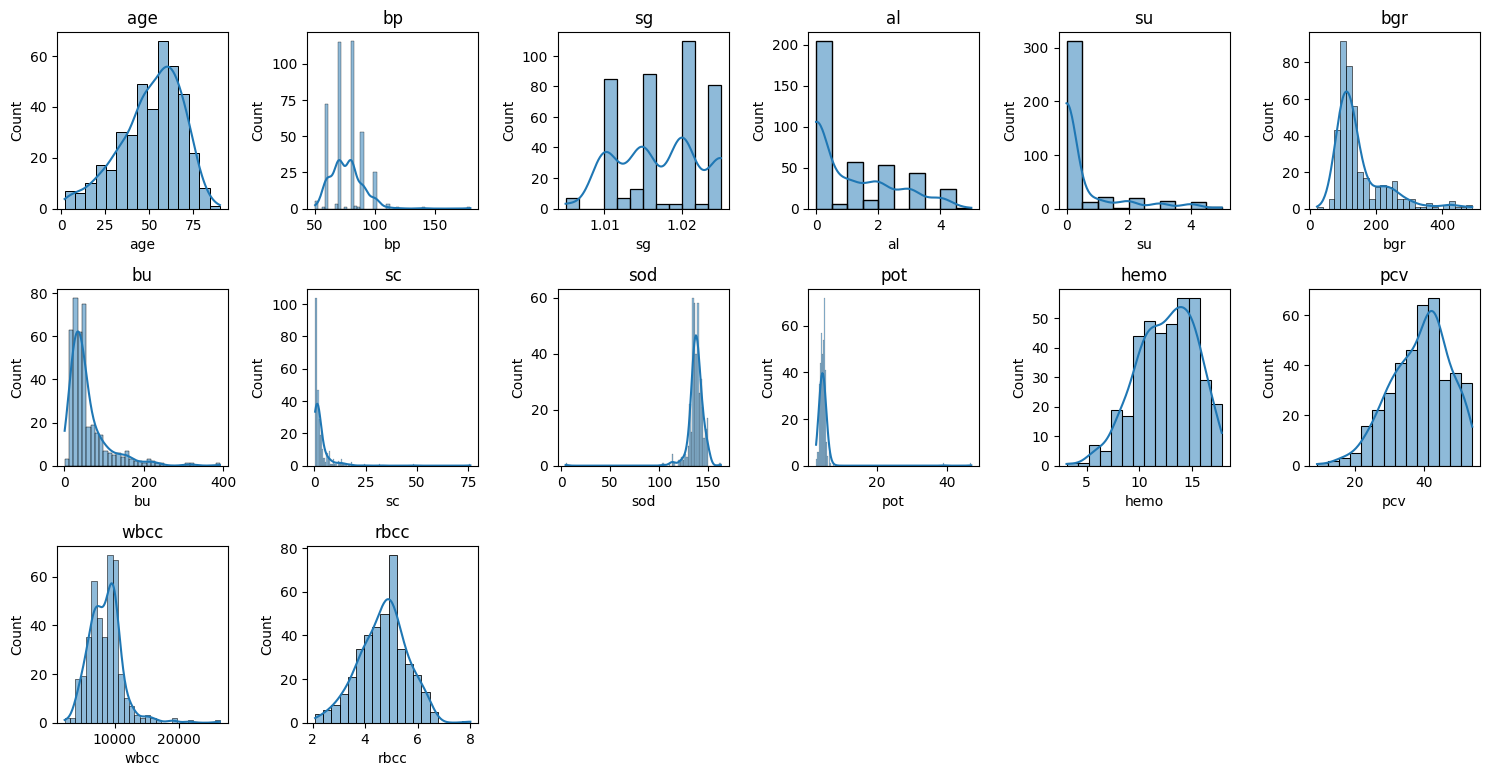

In [11]:
# Histograms for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 6, i + 1)
    sns.histplot(data_imputed[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

<ipython-input-12-1da0320ea9ca>:8: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


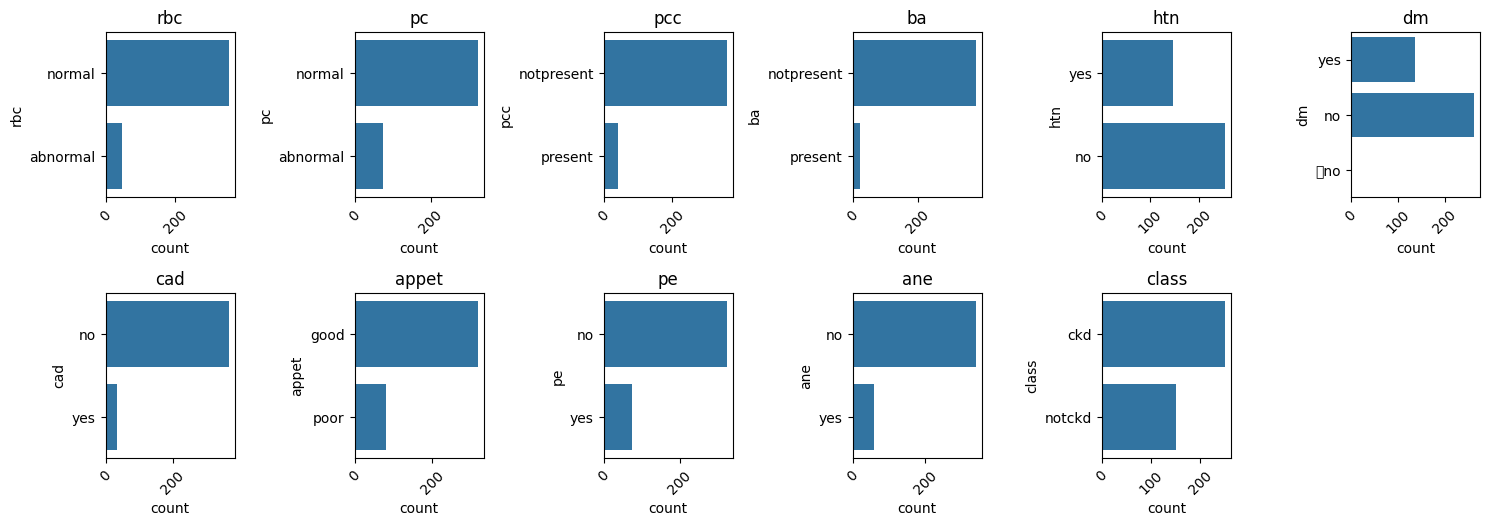

In [12]:
# Count plots for categorical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 6, i + 1)
    sns.countplot(data_imputed[col])
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Bivariate Analysis

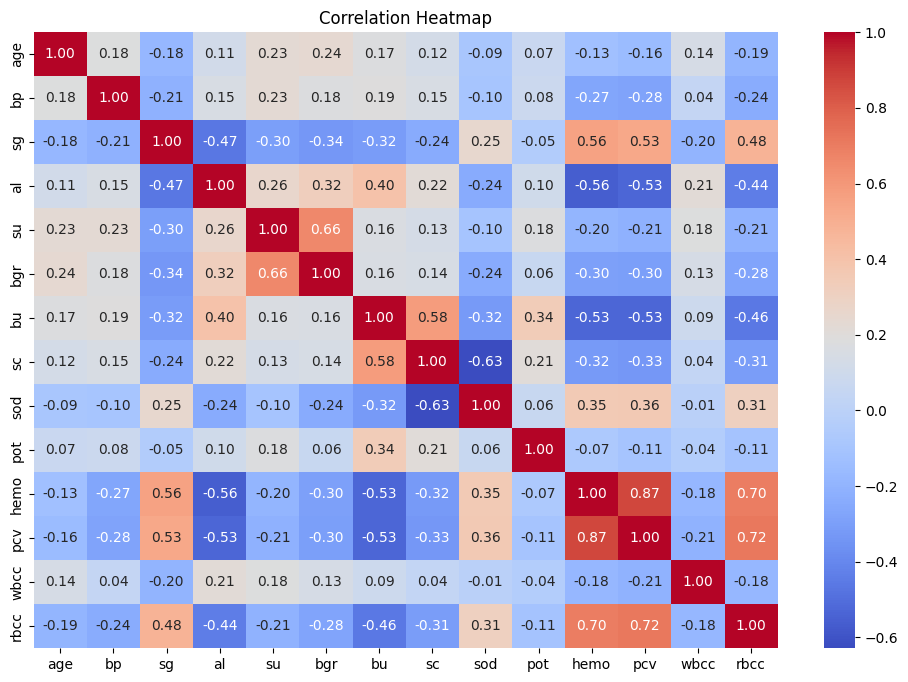

In [13]:
# Correlation heatmap for numerical features
plt.figure(figsize=(12, 8))
sns.heatmap(data_imputed[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

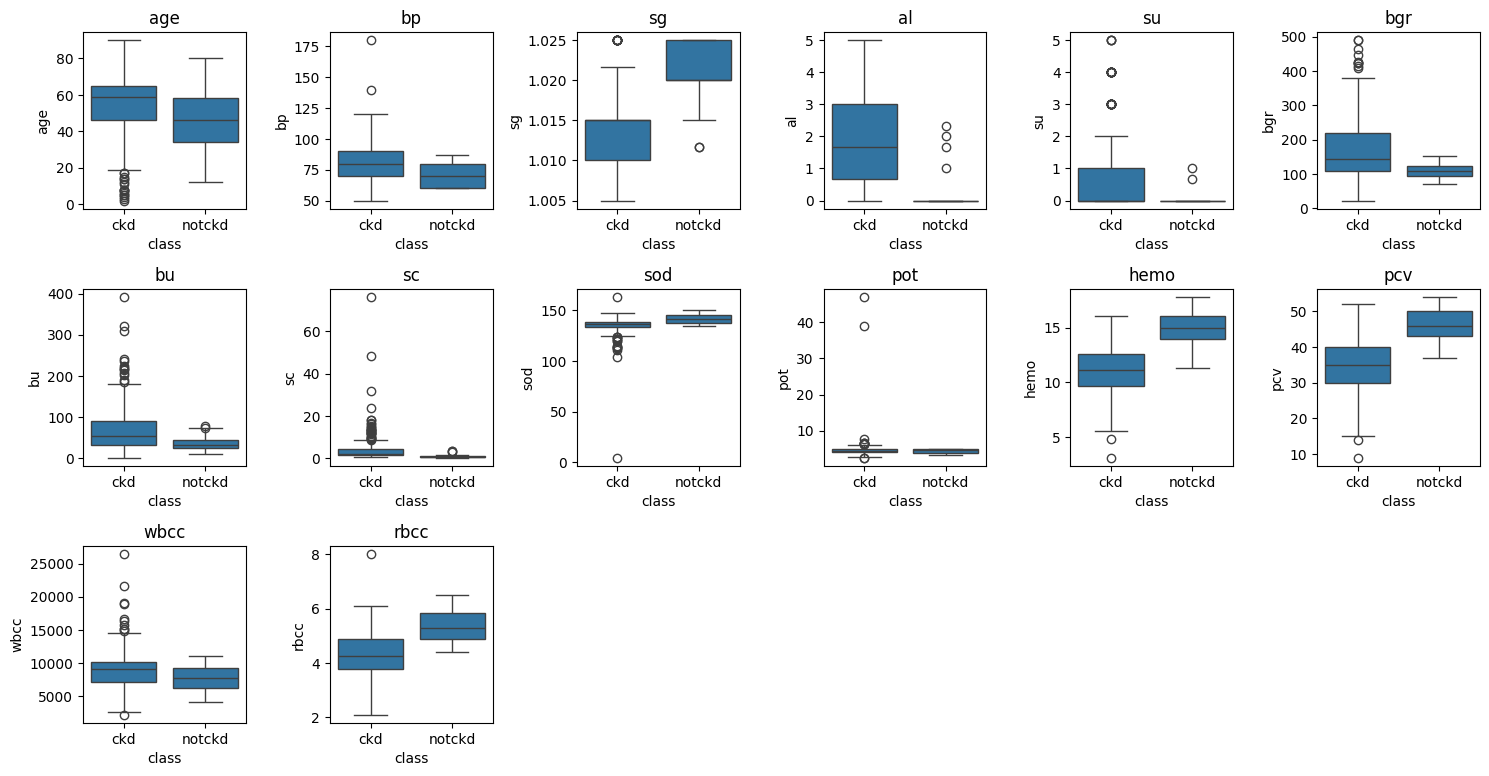

In [14]:
# Boxplots for numerical features vs target variable
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 6, i + 1)
    sns.boxplot(x='class', y=col, data=data_imputed)
    plt.title(col)
plt.tight_layout()
plt.show()

<ipython-input-15-68e71e8c3c40>:8: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


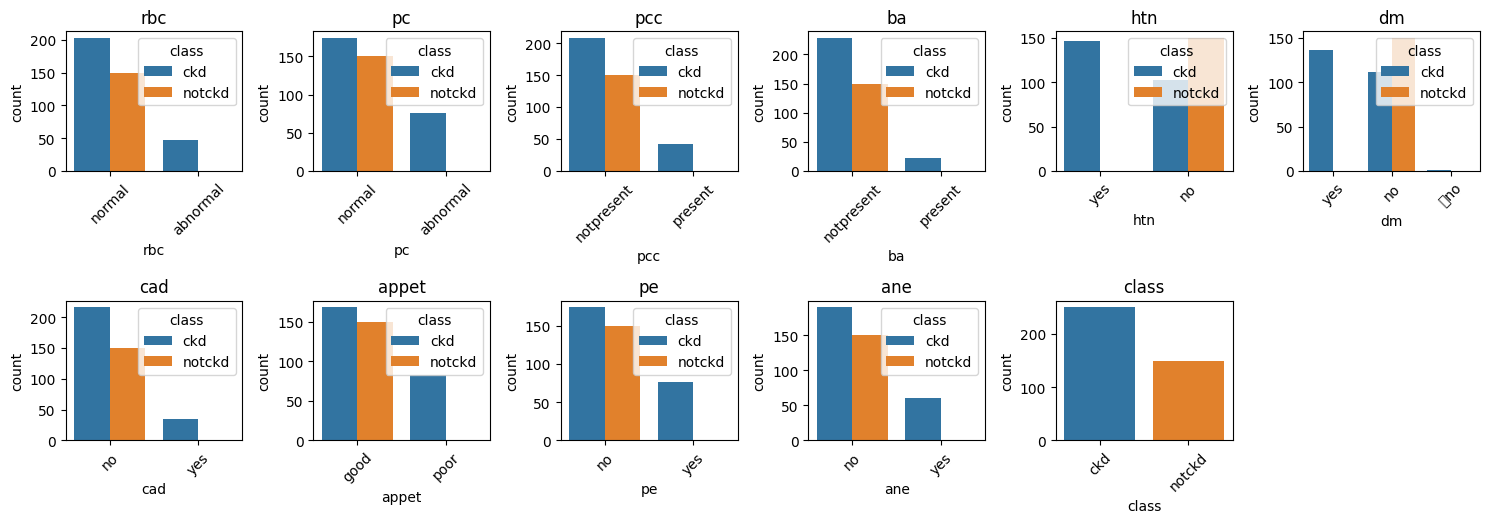

In [15]:
# Count plots for categorical features vs target variable
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 6, i + 1)
    sns.countplot(x=col, hue='class', data=data_imputed)
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Data Preprocessing

In [16]:
# Print value counts for variable 'dm'
print("Value counts for variable 'dm':")
print(data_imputed['dm'].value_counts())

# Replace '\tno' with 'no' in the 'dm' column
data_imputed['dm'] = data_imputed['dm'].replace({'\tno': 'no'})

# Print corrected value counts for variable 'dm'
print("Value counts for variable 'dm' (corrected):")
print(data_imputed['dm'].value_counts())


Value counts for variable 'dm':
dm
no      262
yes     137
\tno      1
Name: count, dtype: int64
Value counts for variable 'dm' (corrected):
dm
no     263
yes    137
Name: count, dtype: int64


In [17]:
# Separate features and target variable
X = data_imputed.drop(columns=['class'])
y = data_imputed['class']

In [18]:
# Define numerical and categorical columns again
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Define column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

In [19]:
# Define the pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Fit and transform the data
X_processed = pipeline.fit_transform(X)

# Convert y to numeric labels
y = y.replace({'ckd': 1, 'notckd': 0})

# Printing first few rows of transformed data
print("First few rows of transformed data:")
print(X_processed[:5])

First few rows of transformed data:
[[-0.1823092   0.27130169  0.51877422 -0.04055469 -0.44284159 -0.36192336
  -0.43680864 -0.33380488  0.16066493 -0.01336028  1.02085685  0.59576082
  -0.27957488  0.5620762   0.          1.          0.          1.
   1.          0.          1.          0.          0.          1.
   0.          1.          1.          0.          1.          0.
   1.          0.          1.          0.        ]
 [-2.5589951  -1.93839534  0.51877422  2.27685625 -0.44284159 -0.45746635
  -0.79961767 -0.40490441 -0.05481192 -0.20211474 -0.45365089 -0.11289239
  -0.96293094  0.78099585  0.          1.          0.          1.
   1.          0.          1.          0.          1.          0.
   1.          0.          1.          0.          1.          0.
   1.          0.          1.          0.        ]
 [ 0.62924208  0.27130169 -1.29617931  0.73191562  2.3938661   3.57271071
  -0.09415566 -0.22715559 -0.59350405  0.03382834 -1.06503214 -0.93965447
  -0.39346756 -0.78792

In [20]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Model Training

In [21]:
# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Bagging': BaggingClassifier(),
    'Boosting': AdaBoostClassifier(),
    'XGBoost': XGBClassifier()
}

# Define evaluation metrics
metrics = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'F1 Score': f1_score
}

In [22]:
# Initialize results table
results = []

# Perform training, testing, and calculate evaluation metrics for each classifier
for clf_name, clf in classifiers.items():
    row = [clf_name]
    clf.fit(X_train, y_train)  # Train the classifier
    y_pred = clf.predict(X_test)  # Predict on the test set
    for metric_name, metric_func in metrics.items():
        metric_value = metric_func(y_test, y_pred)  # Calculate metric
        row.append(metric_value)
    results.append(row)

In [23]:
# Print results table
headers = ['Classifier'] + list(metrics.keys())
print(tabulate(results, headers=headers, tablefmt='grid'))

+---------------------+------------+-------------+----------+------------+
| Classifier          |   Accuracy |   Precision |   Recall |   F1 Score |
+=====================+============+=============+==========+============+
| Logistic Regression |     0.9875 |    0.981132 | 1        |   0.990476 |
+---------------------+------------+-------------+----------+------------+
| Random Forest       |     0.975  |    0.962963 | 1        |   0.981132 |
+---------------------+------------+-------------+----------+------------+
| SVM                 |     0.975  |    0.980769 | 0.980769 |   0.980769 |
+---------------------+------------+-------------+----------+------------+
| KNN                 |     0.9625 |    1        | 0.942308 |   0.970297 |
+---------------------+------------+-------------+----------+------------+
| Naive Bayes         |     0.9875 |    1        | 0.980769 |   0.990291 |
+---------------------+------------+-------------+----------+------------+
| Bagging             |  

# Deep Learning/ Neural Network

Epoch 1/10
8/8 [==============================] - 3s 98ms/step - loss: 0.7884 - accuracy: 0.5117 - val_loss: 0.5736 - val_accuracy: 0.7812
Epoch 2/10
8/8 [==============================] - 0s 12ms/step - loss: 0.6175 - accuracy: 0.6719 - val_loss: 0.4673 - val_accuracy: 0.9219
Epoch 3/10
8/8 [==============================] - 0s 19ms/step - loss: 0.5229 - accuracy: 0.7461 - val_loss: 0.3774 - val_accuracy: 0.9531
Epoch 4/10
8/8 [==============================] - 0s 19ms/step - loss: 0.4410 - accuracy: 0.8047 - val_loss: 0.3079 - val_accuracy: 0.9375
Epoch 5/10
8/8 [==============================] - 0s 28ms/step - loss: 0.4206 - accuracy: 0.8203 - val_loss: 0.2575 - val_accuracy: 0.9531
Epoch 6/10
8/8 [==============================] - 0s 20ms/step - loss: 0.3416 - accuracy: 0.8633 - val_loss: 0.2167 - val_accuracy: 0.9844
Epoch 7/10
8/8 [==============================] - 0s 19ms/step - loss: 0.2894 - accuracy: 0.9023 - val_loss: 0.1814 - val_accuracy: 1.0000
Epoch 8/10
8/8 [===========

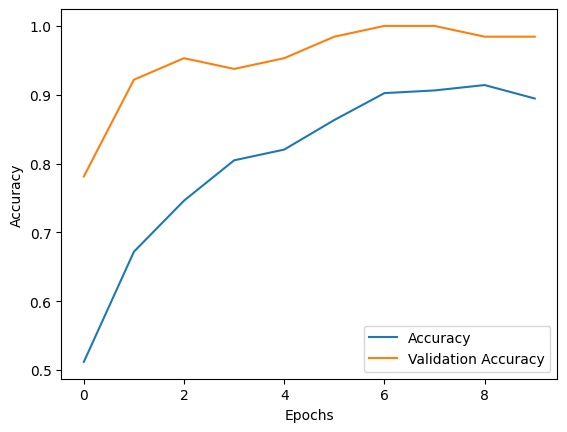

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten  # Add this import statement
from tensorflow.keras.applications import VGG16

# Define neural network classifier
def create_neural_network(input_shape):
    model = Sequential([
        Dense(64, activation='relu', input_shape=input_shape),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create neural network model
neural_network_model = create_neural_network(X_train.shape[1:])

# Train the neural network model
history = neural_network_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the testing set
y_pred = neural_network_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Optionally, you can plot the training history
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()